In [ ]:
!pip install librosa

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
filename='UrbanSound8K/Dog_Bark.wav'

In [ ]:
import IPython.display as ipd
import librosa
import librosa.display

In [ ]:
!dir

 Volume in drive C is OS
 Volume Serial Number is C2D9-1E40

 Directory of C:\Users\Sumit\Music\EnviSOund

01-06-2026  10:01    <DIR>          .
31-05-2026  17:58    <DIR>          ..
31-05-2026  17:59    <DIR>          .ipynb_checkpoints
01-06-2026  10:01           762,024 EnviSound.ipynb
31-05-2026  18:53               880 label_encoder.pkl
31-05-2026  18:35    <DIR>          saved_models
31-05-2026  18:55    <DIR>          UrbanSound8K
               2 File(s)        762,904 bytes
               5 Dir(s)  10,003,083,264 bytes free


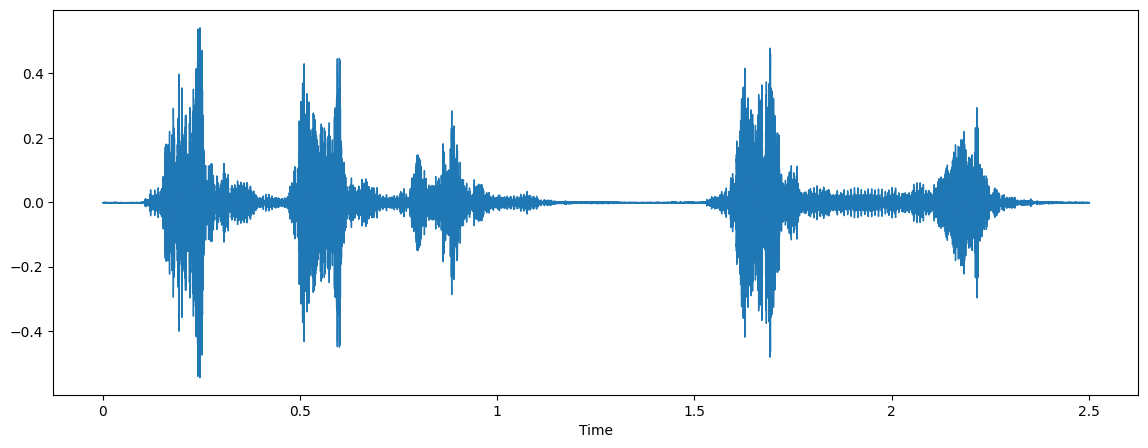

In [ ]:
### Dog Sound
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(filename)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(filename)

In [ ]:
sample_rate

22050

In [ ]:
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio=wav.read(filename)

In [ ]:
wave_sample_rate

44100

In [ ]:
wave_audio

array([[-12, -23],
       [-16, -28],
       [-20, -38],
       ...,
       [-13, -25],
       [-12, -24],
       [-11, -25]], shape=(110250, 2), dtype=int16)

In [ ]:
#librosa give normalize value
data

array([-0.00042261, -0.00086815, -0.00074339, ..., -0.00048444,
       -0.00051792, -0.00059421], shape=(55125,), dtype=float32)

In [ ]:
import pandas as pd

metadata=pd.read_csv('UrbanSound8K/UrbanSound8K/metadata/UrbanSound8K.csv')
metadata.head(10)

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
5,100263-2-0-143.wav,100263,71.500000,75.500000,1,5,2,children_playing
6,100263-2-0-161.wav,100263,80.500000,84.500000,1,5,2,children_playing
7,100263-2-0-3.wav,100263,1.500000,5.500000,1,5,2,children_playing
8,100263-2-0-36.wav,100263,18.000000,22.000000,1,5,2,children_playing
9,100648-1-0-0.wav,100648,4.823402,5.471927,2,10,1,car_horn


In [ ]:
### Check whether the dataset is imbalanced
metadata['class'].value_counts()

class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

In [ ]:
### Let's read a sample audio using librosa
import librosa
audio_file_path='UrbanSound8K/14468-3-0-3.wav'
librosa_audio_data,librosa_sample_rate=librosa.load(audio_file_path)

In [ ]:
print(librosa_audio_data)

[ 0.04017375  0.0593349   0.04329765 ... -0.02508736 -0.01255404
  0.00137326]


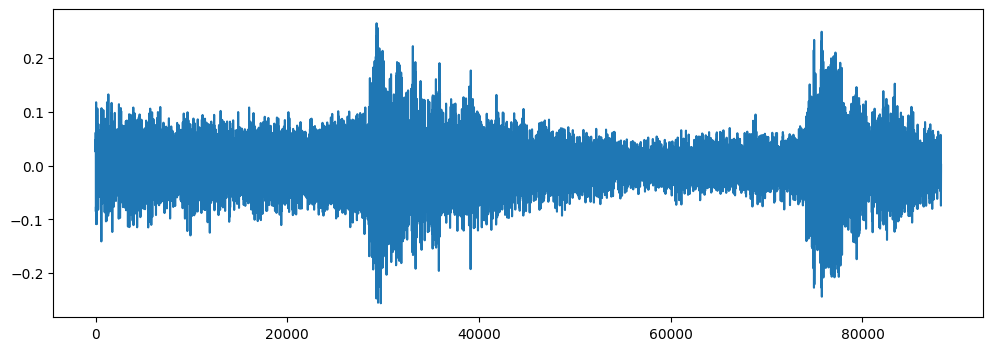

In [ ]:
### Lets plot the librosa audio data
import matplotlib.pyplot as plt
# Original audio with 1 channel 
plt.figure(figsize=(12, 4))
plt.plot(librosa_audio_data)

In [ ]:
#Here Librosa converts the signal to mono, meaning the channel will alays be 1
### Lets read with scipy
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio = wav.read(audio_file_path) 

In [ ]:
wave_audio

array([[1263, 2207],
       [1207, 2478],
       [1000, 2619],
       ...,
       [-792,  423],
       [-654,  732],
       [-633,  988]], shape=(176400, 2), dtype=int16)

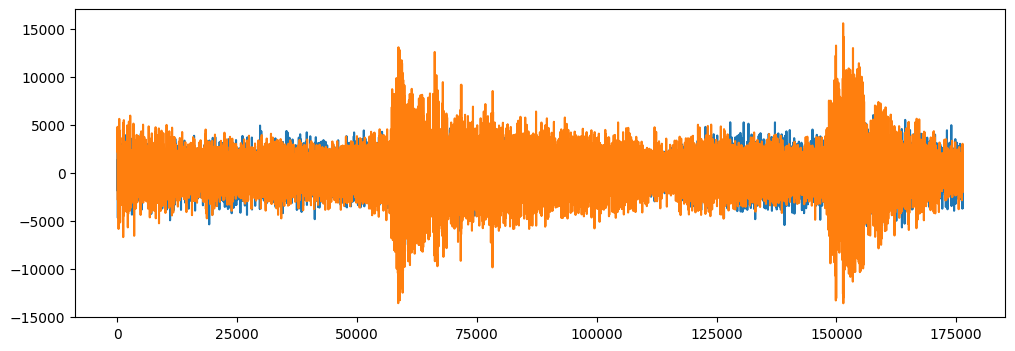

In [ ]:
import matplotlib.pyplot as plt

# Original audio with 2 channels 
plt.figure(figsize=(12, 4))
plt.plot(wave_audio)

In [ ]:
mfccs = librosa.feature.mfcc(y=librosa_audio_data, sr=librosa_sample_rate, n_mfcc=40)
print(mfccs.shape)

(40, 173)


In [ ]:
mfccs

array([[-210.03545   , -182.16873   , -181.77736   , ..., -222.49997   ,
        -225.7789    , -243.34036   ],
       [ 119.56702   ,  117.14458   ,  112.82341   , ...,  133.84543   ,
         132.0702    ,  129.6239    ],
       [ -16.758427  ,  -15.537586  ,   -9.907764  , ...,  -26.848534  ,
         -26.737793  ,  -25.22638   ],
       ...,
       [  -6.159791  ,   -4.79281   ,   -7.9258537 , ...,   -3.1659632 ,
          -4.441354  ,   -2.818585  ],
       [  -2.362619  ,   -3.7120295 ,   -5.889696  , ...,   -6.190593  ,
          -9.438512  ,   -6.4926267 ],
       [  -7.4153833 ,   -8.257313  ,  -11.255264  , ...,   -0.39844394,
          -2.6191788 ,   -5.7330856 ]], shape=(40, 173), dtype=float32)

In [ ]:
#### Extracting MFCC's For every audio file
import pandas as pd
import os
import librosa

audio_dataset_path='UrbanSound8K/UrbanSound8K/audio/'
metadata=pd.read_csv('UrbanSound8K/UrbanSound8K/metadata/UrbanSound8K.csv')
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [ ]:
def features_extractor(file):
    audio, sample_rate = librosa.load(file, res_type='kaiser_fast')

    # audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
    
    return mfccs_scaled_features
    

In [ ]:
!pip install resampy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys
!{sys.executable} -m pip install tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
from tqdm import tqdm
### Now we iterate through every audio file and extract features 
### using Mel-Frequency Cepstral Coefficients
extracted_features=[]
for index_num,row in tqdm(metadata.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_dataset_path),'fold'+str(row["fold"])+'/',str(row["slice_file_name"]))
    final_class_labels=row["class"]
    data=features_extractor(file_name)
    extracted_features.append([data,final_class_labels])

2013it [01:20, 26.43it/s]

In [ ]:
### converting extracted_features to Pandas dataframe
extracted_features_df=pd.DataFrame(extracted_features,columns=['feature','class'])
extracted_features_df.head()

In [ ]:
### Split the dataset into independent and dependent dataset
X=np.array(extracted_features_df['feature'].tolist())
y=np.array(extracted_features_df['class'].tolist())

In [ ]:
X.shape

In [ ]:
y     

In [ ]:
### Label Encoding
###y=np.array(pd.get_dummies(y))
### Label Encoder
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
y=to_categorical(labelencoder.fit_transform(y))

In [ ]:
y.shape

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
X_train

In [ ]:
y

In [ ]:
X_train.shape

In [ ]:
X_test.shape

In [ ]:
y_train.shape

In [ ]:
y_test.shape

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
print(tf.__version__)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics

In [ ]:
### No of classes
num_labels=y.shape[1]

In [ ]:
model=Sequential()
###first layer
model.add(Dense(100,input_shape=(40,)))
model.add(Activation('relu'))
model.add(Dropout(0.5))
###second layer
model.add(Dense(200))
model.add(Activation('relu'))
model.add(Dropout(0.5))
###third layer
model.add(Dense(100))
model.add(Activation('relu'))
model.add(Dropout(0.5))

###final layer
model.add(Dense(num_labels))
model.add(Activation('softmax'))

In [ ]:
model.summary()

In [ ]:
model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='adam')

In [ ]:
## Trianing my model
from tensorflow.keras.callbacks import ModelCheckpoint
from datetime import datetime 

num_epochs = 100
num_batch_size = 32

checkpointer = ModelCheckpoint(filepath='saved_models/audio_classification.keras', 
                               verbose=1, save_best_only=True)
start = datetime.now()

model.fit(X_train, y_train, batch_size=num_batch_size, epochs=num_epochs, validation_data=(X_test, y_test), callbacks=[checkpointer], verbose=1)


duration = datetime.now() - start
print("Training completed in time: ", duration)

In [ ]:
test_accuracy=model.evaluate(X_test,y_test,verbose=0)
print(test_accuracy[1])


In [ ]:
# =========================
# Save Label Encoder (IMPORTANT)
# =========================
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(labelencoder, f)

print("✅ Label Encoder saved!")

# NOTE:
# Your model is ALREADY saved by ModelCheckpoint:
# saved_models/audio_classification.keras

In [1]:
from tensorflow.keras.models import load_model
import pickle

# Load best saved model
model = load_model("saved_models/audio_classification.keras")

# Load label encoder
with open("label_encoder.pkl", "rb") as f:
    labelencoder = pickle.load(f)

print("✅ Model and Encoder Loaded Successfully!")

✅ Model and Encoder Loaded Successfully!


In [2]:
import numpy as np
import librosa

# =========================
# Function for prediction
# =========================
def predict_sound(file_path):
    audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
    
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T, axis=0)
    
    mfccs_scaled_features = mfccs_scaled_features.reshape(1, -1)
    
    prediction = model.predict(mfccs_scaled_features)
    predicted_label = np.argmax(prediction, axis=1)
    
    predicted_class = labelencoder.inverse_transform(predicted_label)
    
    return predicted_class[0]

# =========================
# Test with file
# =========================
filename = "UrbanSound8K/car_horn.wav"

result = predict_sound(filename)

print("🎯 Predicted Sound:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
🎯 Predicted Sound: car_horn


In [3]:
pip install sounddevice

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sounddevice as sd
import numpy as np
import librosa
import pickle
from tensorflow.keras.models import load_model

# Load model
model = load_model("saved_models/audio_classification.keras")

# Load label encoder
with open("label_encoder.pkl", "rb") as f:
    labelencoder = pickle.load(f)

# Prediction function
def predict_audio(audio, sample_rate=22050):

    mfccs_features = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    mfccs_scaled_features = np.mean(
        mfccs_features.T,
        axis=0
    )

    mfccs_scaled_features = mfccs_scaled_features.reshape(1, -1)

    prediction = model.predict(
        mfccs_scaled_features,
        verbose=0
    )

    predicted_label = np.argmax(
        prediction,
        axis=1
    )

    predicted_class = labelencoder.inverse_transform(
        predicted_label
    )

    confidence = np.max(prediction)

    return predicted_class[0], confidence


# Real Time Loop
sample_rate = 22050
duration = 2

print("🎤 Listening... Press CTRL+C to stop")

while True:

    audio = sd.rec(
        int(duration * sample_rate),
        samplerate=sample_rate,
        channels=1,
        dtype='float32',
        device=3  # Realtek Microphone Array
    )

    sd.wait()

    audio = audio.flatten()

    # Check volume
    volume = np.abs(audio).mean()
    print("Volume:", volume)

    if volume < 0.01:
        print("No significant sound detected")
        continue

    sound, confidence = predict_audio(
        audio,
        sample_rate
    )

    print(
        f"Detected: {sound} | Confidence: {confidence:.2f}"
    )

In [6]:
import sounddevice as sd

print(sd.query_devices())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Microphone (DroidCam Virtual Au, MME (1 in, 0 out)
   2 AI Noise-cancelling Input (ASUS, MME (2 in, 0 out)
   3 Microphone Array (Realtek(R) Au, MME (2 in, 0 out)
   4 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  5 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   6 AI Noise-cancelling Output (ASU, MME (0 in, 2 out)
   7 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   8 Microphone (DroidCam Virtual Audio), Windows DirectSound (1 in, 0 out)
   9 AI Noise-cancelling Input (ASUS Utility), Windows DirectSound (2 in, 0 out)
  10 Microphone Array (Realtek(R) Audio), Windows DirectSound (2 in, 0 out)
  11 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  12 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  13 AI Noise-cancelling Output (ASUS Utility), Windows DirectSound (0 in, 2 out)
  14 Speakers (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
  15 AI Noise-cancelling Output (ASUS

In [7]:
import sounddevice as sd

print(sd.default.device)

[1, 5]
